In [876]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['estermannufer'].sum())
header = 'estermannufer'

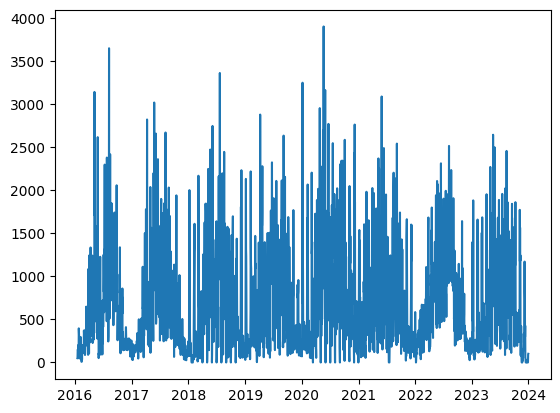

In [877]:
plt.plot(df[header])

In [878]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [879]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

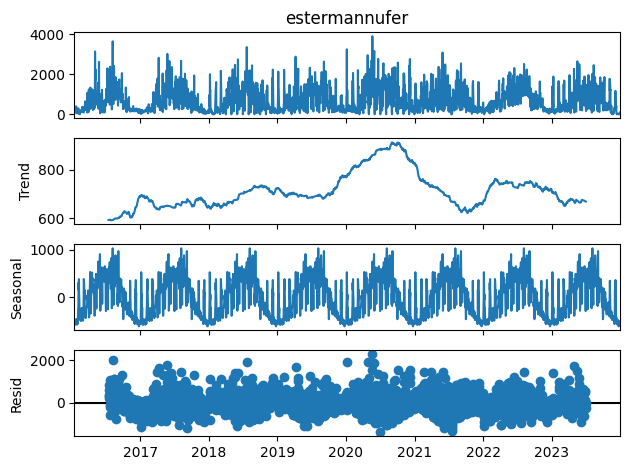

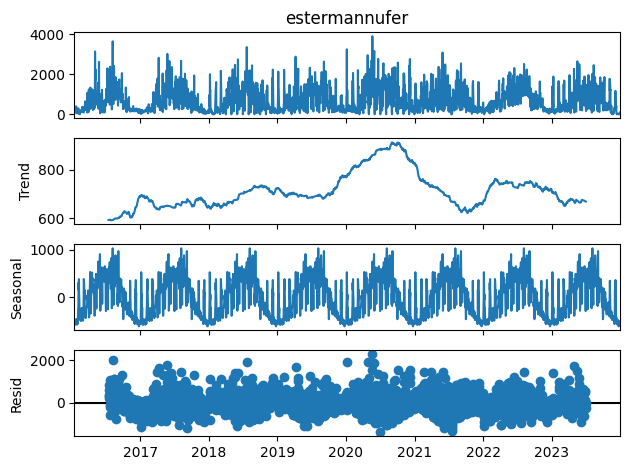

In [880]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [881]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['estermannufer'])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.9433
p-value = 0.0017


In [882]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [883]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [884]:
df_train.loc[:,'differences'] = df_train.loc[:,'estermannufer'].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_5392\2673430208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,'estermannufer'].diff(periods=365)


Test statistic = -7.2765
P-value = 0.0000


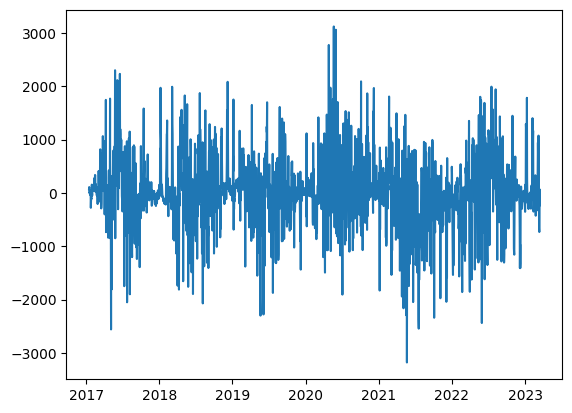

In [885]:
plt.plot(df_train.loc[:,'differences'] )

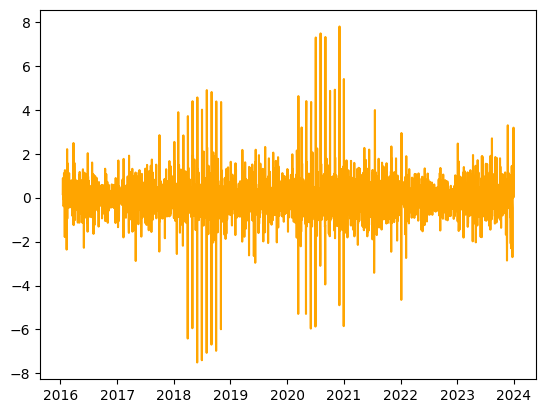

In [886]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [887]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -22.9752
P-value = 0.0000


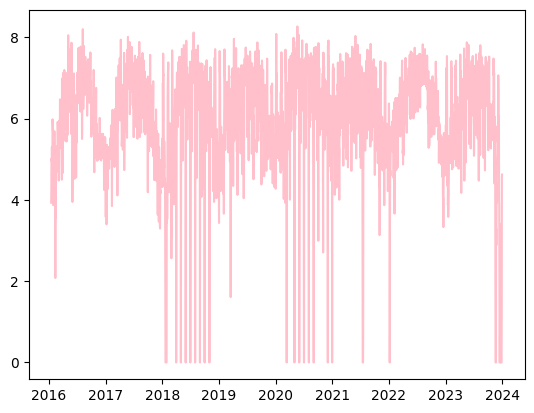

In [888]:
plt.plot(df['log'], color='pink')

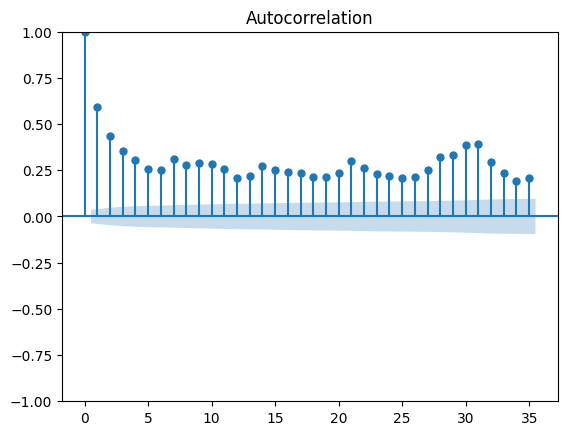

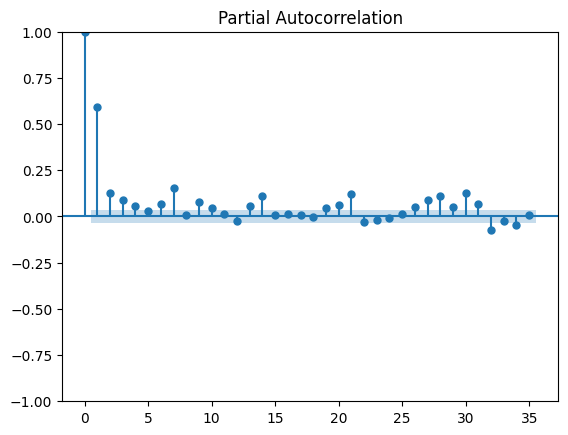

In [889]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [890]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [891]:
def ma_arima():
    for i in range(1, 3):
        p, d, q = i, 0, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='yellow', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -3645.5262, AIC: 7295.0524


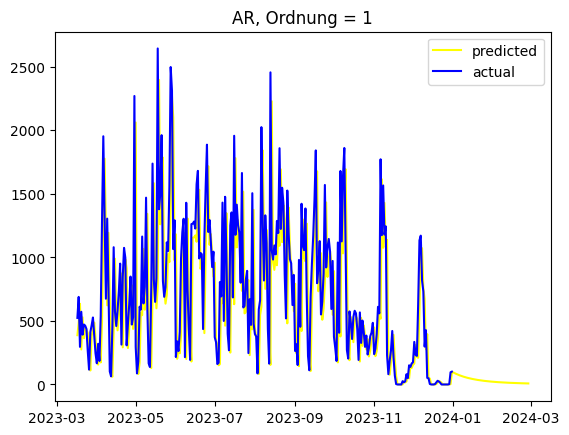

mean absolute error (mae): ARIMA: 723.5368, simple: 354.2379
mean squared error (mse): ARIMA: 829680.2138, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.5969, simple: 0.6210
Log Likelihood: -3556.2479, AIC: 7118.4958


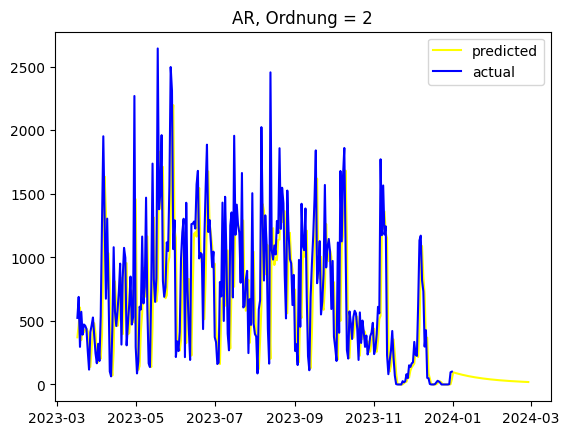

mean absolute error (mae): ARIMA: 723.5377, simple: 354.2379
mean squared error (mse): ARIMA: 829678.7434, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.6763, simple: 0.6210
Log Likelihood: -3515.8550, AIC: 7039.7100


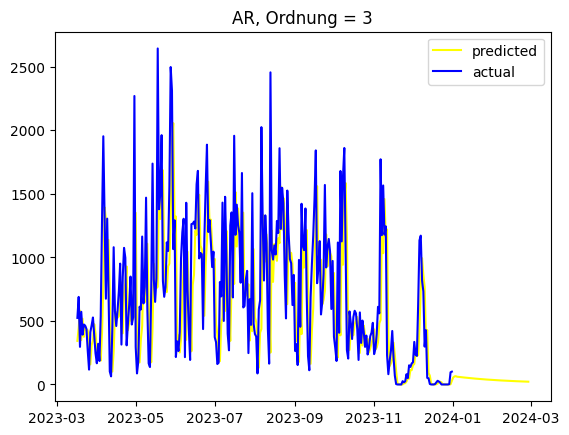

mean absolute error (mae): ARIMA: 723.5478, simple: 354.2379
mean squared error (mse): ARIMA: 829690.4480, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.7227, simple: 0.6210
Log Likelihood: -3488.1545, AIC: 6986.3091


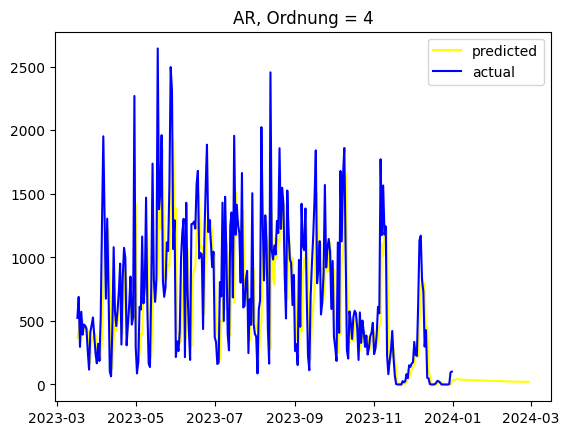

mean absolute error (mae): ARIMA: 723.5572, simple: 354.2379
mean squared error (mse): ARIMA: 829691.1726, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.7337, simple: 0.6210


In [892]:
for i in range(1, 5):
    p, d, q = i, 0, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [893]:
df_r

,estermannufer,scaled,log,differences,predicted_mean,crossings
2016-01-16,50.000000,50.987183,3.931574,NaN,NaN,NaN
2016-01-17,59.000000,59.984876,4.094092,NaN,NaN,NaN
2016-01-18,145.000000,145.962830,4.983352,NaN,NaN,NaN
2016-01-19,151.000000,151.961292,5.023626,NaN,NaN,NaN
2016-01-20,141.000000,141.963855,4.955572,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,20.785155,NaN,NaN,NaN,3.080984,20.785155
2024-02-25,20.534909,NaN,NaN,NaN,3.069431,20.534909
2024-02-26,20.288459,NaN,NaN,NaN,3.057921,20.288459
2024-02-27,20.045739,NaN,NaN,NaN,3.046454,20.045739


Log Likelihood: -3645.5262, AIC: 7295.0524


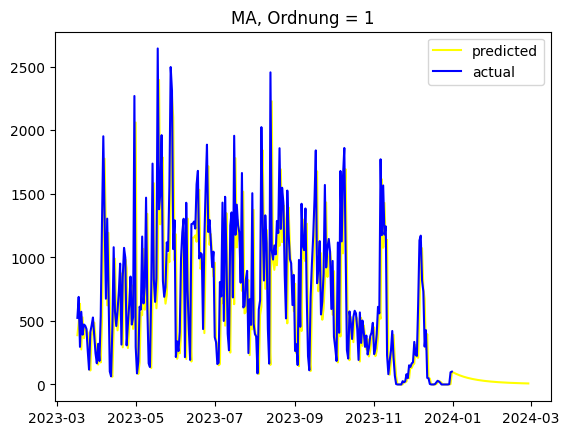

mean absolute error (mae): ARIMA: 723.5368, simple: 354.2379
mean squared error (mse): ARIMA: 829680.2138, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.5969, simple: 0.6210
Log Likelihood: -3556.2479, AIC: 7118.4958


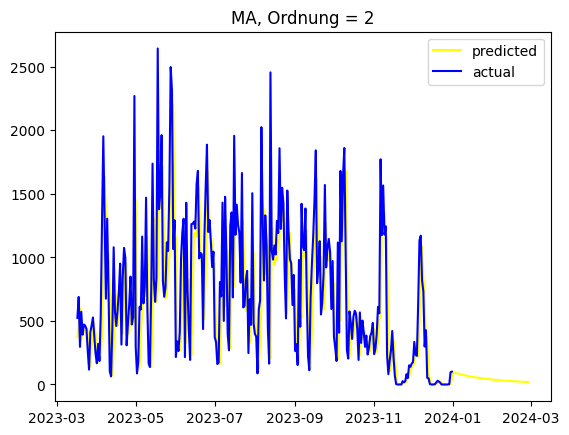

mean absolute error (mae): ARIMA: 723.5377, simple: 354.2379
mean squared error (mse): ARIMA: 829678.7434, simple: 270162.1483
mean absolute percentage error (mape): ARIMA: 0.6763, simple: 0.6210


In [894]:
ma_arima()

Seasonal ARIMA

In [895]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,2932,4172,9020,18393,31823,11871,36468,40001,32755,13716,7687,6146
2017,4225,6486,17575,20038,31116,35957,34586,34693,20424,16800,9483,3641
2018,7996,10877,14350,26432,31915,26887,37570,31103,22918,20321,13140,13054
2019,12111,17733,14602,25150,24374,31811,30876,29963,22633,18624,11920,10706
2020,15159,13099,21576,32656,41642,34204,41801,33159,31453,20650,19603,18560
2021,15596,21085,22494,23068,25922,28282,16989,28018,28074,17412,12597,12876
2022,6945,8898,21790,21891,32388,33210,37666,41735,22851,20958,11899,5027
2023,10211,12756,15964,22248,32168,29708,26696,31986,26500,18233,11144,6573


In [896]:
#Mittelwertbereinigung
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['log'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,estermannufer,scaled,log,first_logged_diff,differences,days_noyear,day_mean,cleaned_by_mean
2016-01-16,50,50.987183,3.931574,NaN,NaN,01-16,5.140729,-1.209155
2016-01-17,59,59.984876,4.094092,0.162518,NaN,01-17,4.772480,-0.678388
2016-01-18,145,145.962830,4.983352,0.889260,NaN,01-18,5.063975,-0.080623
2016-01-19,151,151.961292,5.023626,0.040274,NaN,01-19,4.919864,0.103762
2016-01-20,141,141.963855,4.955572,-0.068053,NaN,01-20,4.902214,0.053359
...,...,...,...,...,...,...,...,...
2023-12-27,0,1.000000,0.000000,0.000000,NaN,12-27,4.503216,-4.503216
2023-12-28,0,1.000000,0.000000,0.000000,NaN,12-28,4.656194,-4.656194
2023-12-29,3,3.999231,1.386102,1.386102,NaN,12-29,4.830509,-3.444407
2023-12-30,96,96.975391,4.574457,3.188355,NaN,12-30,5.198080,-0.623622


In [897]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    650.330120
1    656.231325
2    671.108434
3    663.906024
4    649.320482
5    727.108173
6    899.747596
Name: estermannufer, dtype: float64


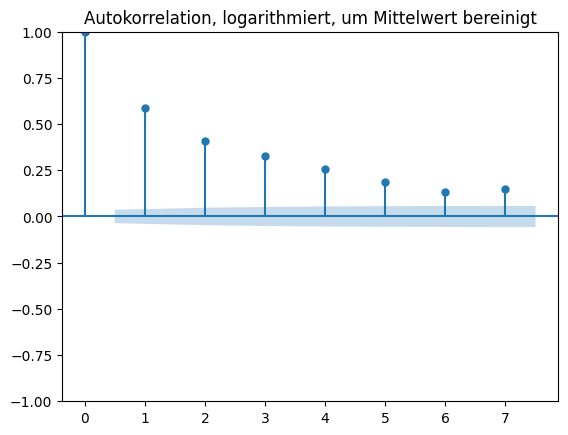

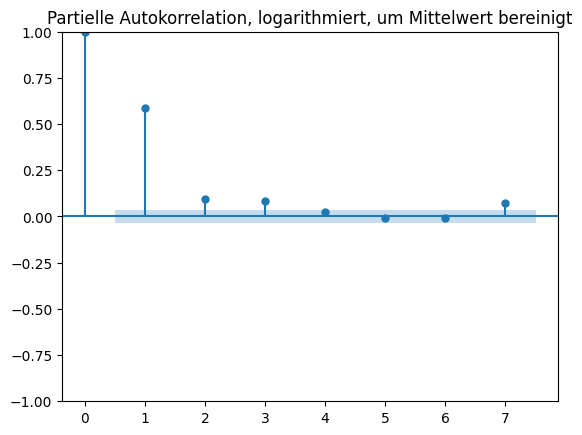

In [898]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

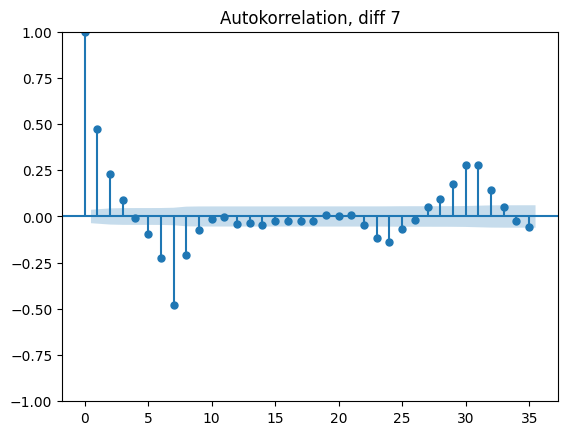

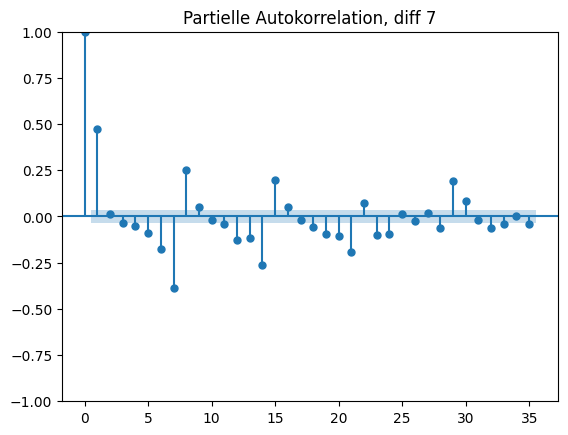

In [899]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [900]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

ARIMA (0,0,0)x(0,1,0,7) LL -4197.8432, AIC: 8397.6864
ARIMA (0,1,0)x(0,1,0,7) LL -4081.6970, AIC: 8165.3940
ARIMA (1,0,0)x(0,1,1,7) LL -3106.4349, AIC: 6218.8698
ARIMA (1,0,0)x(0,1,2,7) LL -3100.7236, AIC: 6209.4473
ARIMA (1,1,0)x(0,1,2,7) LL -3257.9800, AIC: 6523.9600
ARIMA (0,0,1)x(0,1,2,7) LL -3276.1780, AIC: 6560.3559
ARIMA (0,1,1)x(0,1,2,7) LL -3211.2072, AIC: 6430.4144
ARIMA (0,1,1)x(2,1,0,7) LL -3495.8333, AIC: 6999.6666


In [901]:
print(result4.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                    log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -3100.724
Date:                                Sun, 09 Feb 2025   AIC                           6209.447
Time:                                        22:01:16   BIC                           6232.443
Sample:                                    01-16-2016   HQIC                          6217.828
                                         - 05-29-2022                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6279      0.009     73.462      0.000       0.611       0.645
ma.

In [902]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-12-31')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


            predicted_mean    unlogged  new_predict
2022-05-30        6.183006  484.446249   483.570209
2022-05-31        6.175012  480.588778   479.711750
2022-06-01        6.292631  540.573490   539.711842
2022-06-02        6.115987  453.043139   452.159048
2022-06-03        6.148629  468.075422   467.195185
...                    ...         ...          ...
2024-12-27        6.092735  442.630430   441.743669
2024-12-28        6.199435  492.470736   491.596754
2024-12-29        6.296499  542.668957   541.807846
2024-12-30        6.100110  445.906637   445.020716
2024-12-31        6.128527  458.759964   457.877339

[947 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

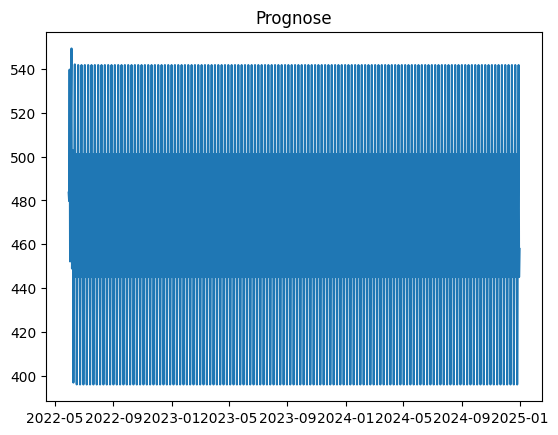

In [903]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

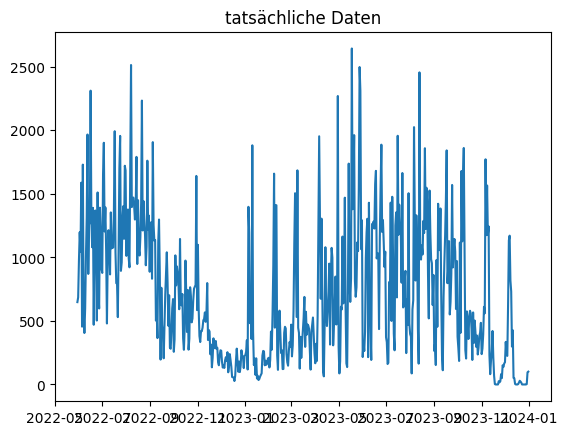

In [904]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [905]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

,predicted_mean,unlogged,final_data
2022-05-30,6.183006,484.446249,483.570209
2022-05-31,6.358460,577.356352,576.504136
2022-06-01,6.516825,676.427447,675.600633
2022-06-02,6.488725,657.684140,656.852520
2022-06-03,6.759556,862.259113,861.479948
...,...,...,...
2024-12-27,6.025391,413.803477,412.909324
2024-12-28,6.045508,422.212114,421.320117
2024-12-29,6.146058,466.873296,465.992751
2024-12-30,6.020469,411.771652,410.876978


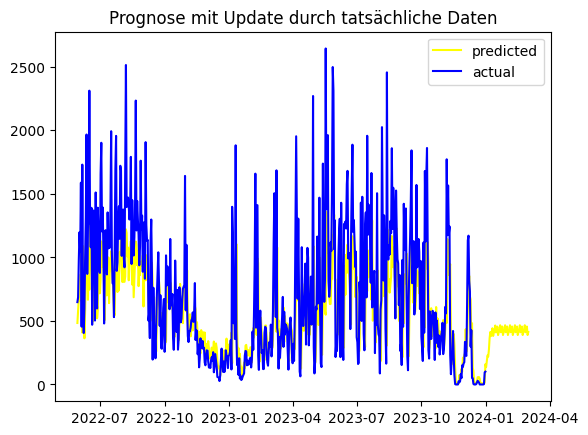

In [906]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [907]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_5392\1728239483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_5392\1728239483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_539

mean absolute error (mae): ARIMA: 294.6030
mean squared error (mse): ARIMA: 183656.8488
mean absolute percentage error (mape): ARIMA: 0.4270


Monatlich


In [908]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1      9396.875
2     11888.250
3     17171.375
4     23734.500
5     31418.500
6     28991.250
7     32831.500
8     33832.250
9     25951.000
10    18339.250
11    12184.125
12     9572.875
Name: estermannufer, dtype: float64


In [909]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [910]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [911]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,estermannufer
year-month,,
2016-01-01,2016-01-01,2932
2016-02-01,2016-02-01,4172
2016-03-01,2016-03-01,9020
2016-04-01,2016-04-01,18393
2016-05-01,2016-05-01,31823
...,...,...
2023-08-01,2023-08-01,31986
2023-09-01,2023-09-01,26500
2023-10-01,2023-10-01,18233


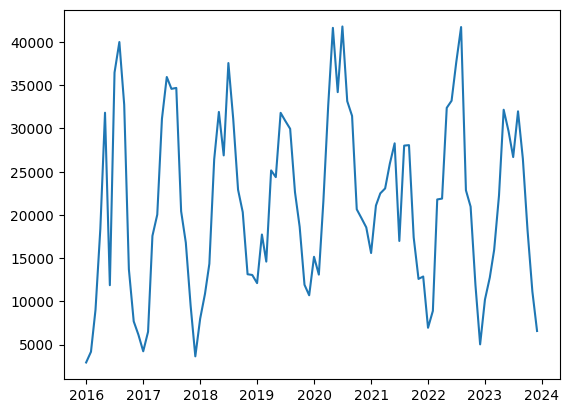

In [912]:
plt.plot(df_month[header])

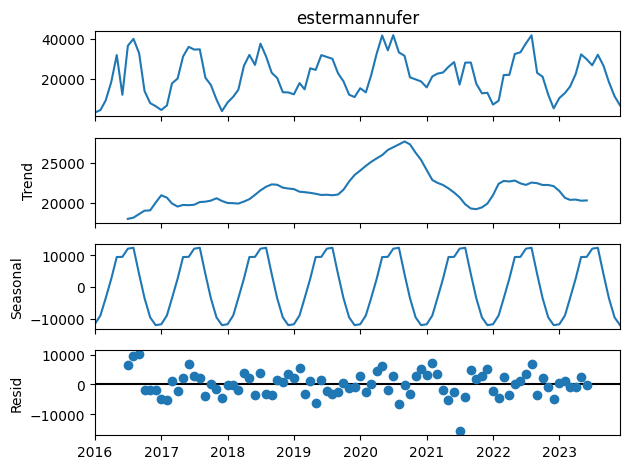

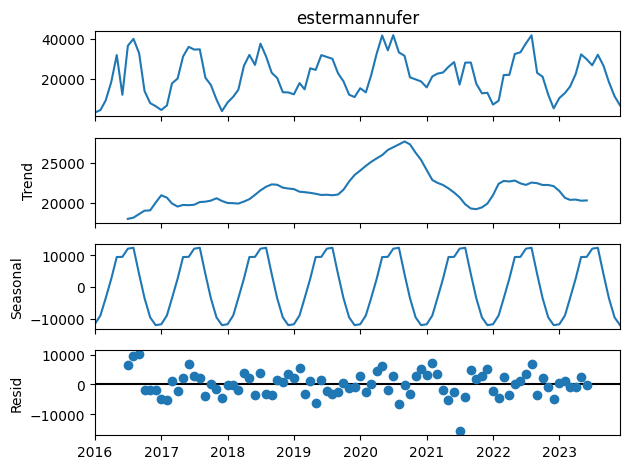

In [913]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [914]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -8.4249
p-value = 0.0000


In [915]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,estermannufer,scaled,log
year-month,,,,
2016-01-01,2016-01-01,2932,1.000000,0.000000
2016-02-01,2016-02-01,4172,1334.504850,7.196316
2016-03-01,2016-03-01,9020,6548.078649,8.786927
2016-04-01,2016-04-01,18393,16627.869742,9.718835
2016-05-01,2016-05-01,31823,31070.587589,10.344017
...,...,...,...,...
2023-08-01,2023-08-01,31986,31245.878952,10.349643
2023-09-01,2023-09-01,26500,25346.195400,10.140384
2023-10-01,2023-10-01,18233,16455.804600,9.708434


In [916]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [917]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -5.2986
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_5392\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


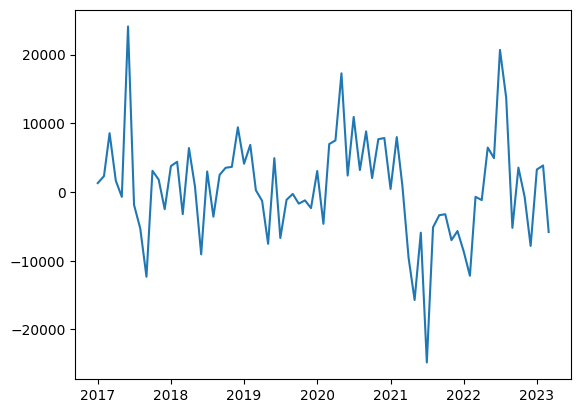

In [918]:
plt.plot(df_train['differences'])

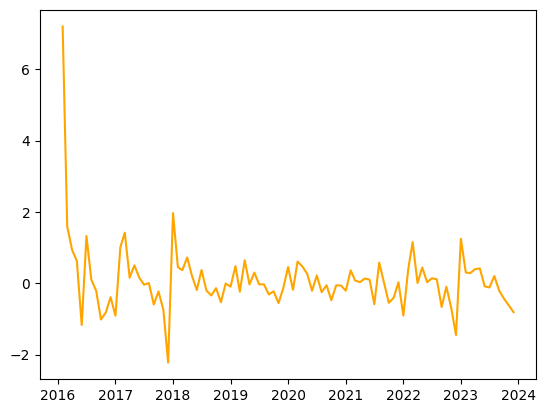

In [919]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [920]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -8.6349
P-value = 0.0000


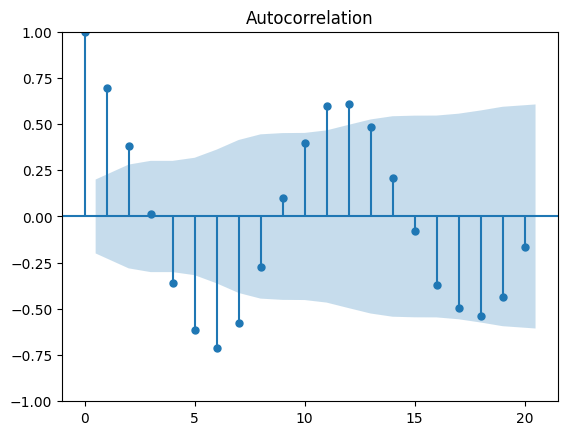

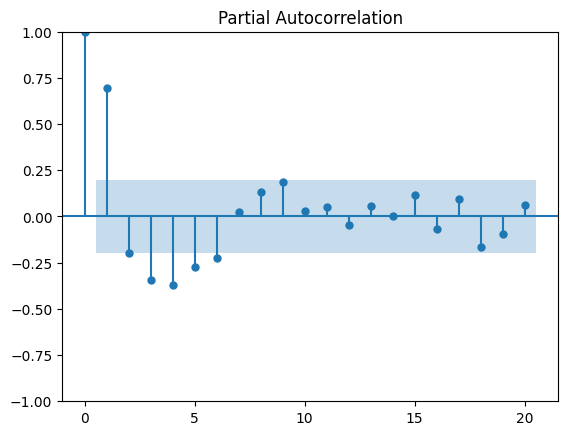

In [921]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [922]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,estermannufer,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,2932,1.000000,0.000000,NaN,1,7.672210,-7.672210
2016-02-01,2016-02-01,4172,1334.504850,7.196316,7.196316,2,8.923066,-1.726751
2016-03-01,2016-03-01,9020,6548.078649,8.786927,1.590611,3,9.578773,-0.791846
2016-04-01,2016-04-01,18393,16627.869742,9.718835,0.931909,4,9.997167,-0.278332
2016-05-01,2016-05-01,31823,31070.587589,10.344017,0.625181,5,10.315963,0.028054
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,31986,31245.878952,10.349643,0.200977,8,10.401110,-0.051467
2023-09-01,2023-09-01,26500,25346.195400,10.140384,-0.209259,9,10.100430,0.039954
2023-10-01,2023-10-01,18233,16455.804600,9.708434,-0.431950,10,9.703481,0.004952


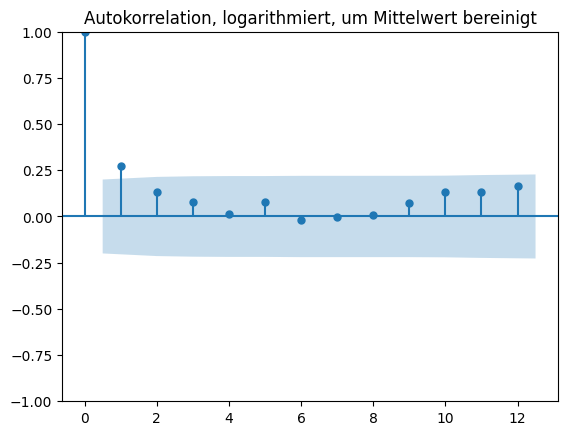

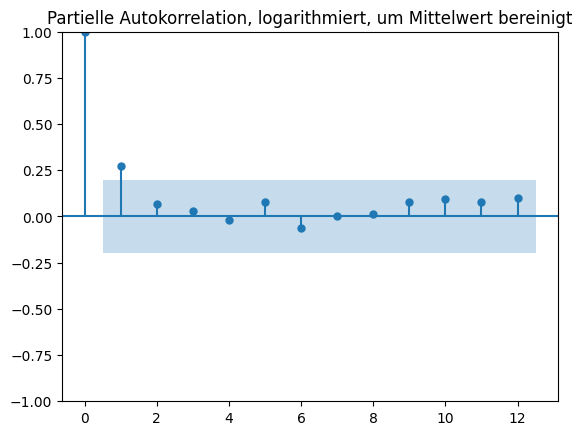

In [923]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

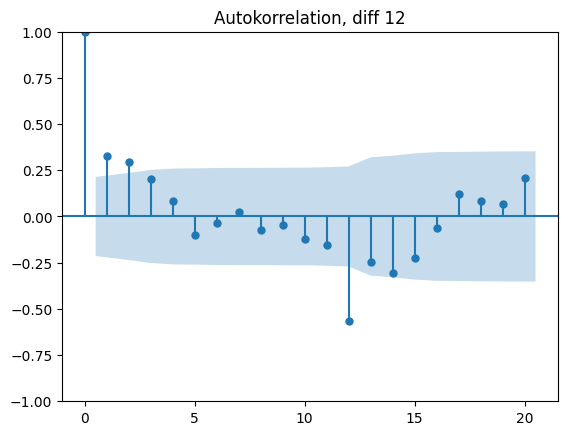

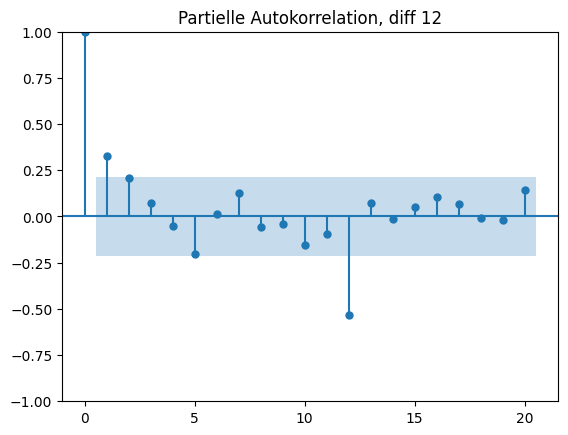

In [924]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [925]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -109.4366, AIC: 220.8731
ARIMA (0,1,0)x(0,1,0,12) LL -109.3440, AIC: 220.6881
ARIMA (1,0,0)x(0,1,1,12) LL -106.2846, AIC: 218.5693
ARIMA (1,0,0)x(0,1,2,12) LL -105.1472, AIC: 218.2943
ARIMA (1,1,0)x(0,1,2,12) LL -104.3078, AIC: 216.6156
ARIMA (0,0,1)x(0,1,2,12) LL -105.9595, AIC: 219.9190
ARIMA (0,1,1)x(0,1,2,12) LL -103.3910, AIC: 212.7820
ARIMA (0,1,1)x(2,1,0,12) LL -103.8586, AIC: 215.7171


In [926]:
print(result7.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(0, 1, 1)x(0, 1, [2], 12)   Log Likelihood                -103.391
Date:                              Sun, 09 Feb 2025   AIC                            212.782
Time:                                      22:02:38   BIC                            219.694
Sample:                                  01-01-2016   HQIC                           215.539
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5771      0.076     -7.629      0.000      -0.725      -0.429
ma.S.L24       0.42

In [927]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean      unlogged   new_predict
2023-04-01        9.531239  13783.655463  15748.220938
2023-05-01        9.951126  20975.836404  22436.088904
2023-06-01       10.107691  24530.963888  25741.932210
2023-07-01        9.890185  19735.716523  21282.925754
2023-08-01       10.314414  30164.283733  30980.245824
2023-09-01        9.644788  15441.093284  17289.439853
2023-10-01        9.577138  14431.065268  16350.234615
2023-11-01        8.743003   6266.685539   8758.338068
2023-12-01        7.238443   1391.925322   4225.394171
2024-01-01        8.273514   3918.696418   6574.989045
2024-02-01        8.668523   5816.902941   8340.094053
2024-03-01        9.192248   9820.699702  12063.146118
2024-04-01        9.231539  10214.253480  12429.104055
2024-05-01        9.711157  16500.681859  18274.730483
2024-06-01        9.905029  20030.846889  21557.361692
2024-07-01        9.975570  21494.881158  22918.738438
2024-08-01       10.227465  27652.317219  28644.417440
2024-09-01

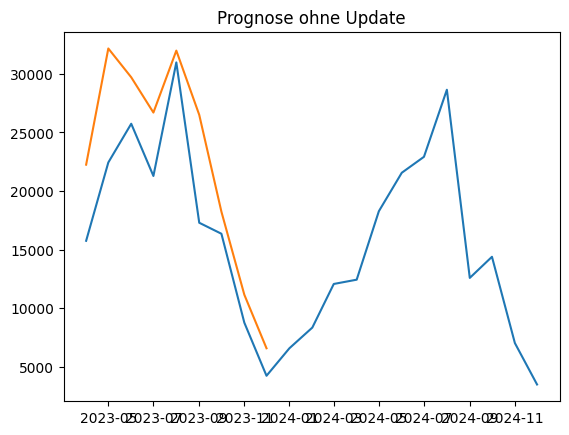

mean absolute error (mae): ARIMA: 4715.9089
mean squared error (mse): ARIMA: 31397965.4579
mean absolute percentage error (mape): ARIMA: 0.2205


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_5392\1074150843.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_5392\1074150843.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel

In [928]:
plt.plot(y_pred_no_update['new_predict'])
plt.plot(df_test_seas[header])

plt.title('Prognose ohne Update')
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [929]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,9.531239,13783.655463,15748.220938
2023-05-01,10.124621,24949.785539,26131.386247
2023-06-01,10.378992,32176.507231,32851.372979
2023-07-01,10.114545,24699.663196,25898.802386
2023-08-01,10.553203,38299.918775,38545.413250
2023-09-01,9.797492,17988.565174,19658.283989
2023-10-01,9.874851,19435.387926,21003.656083
2023-11-01,8.970338,7866.258009,10245.749128
2023-12-01,7.514761,1834.928591,4637.334220
2024-01-01,8.870476,7118.668939,9550.580718


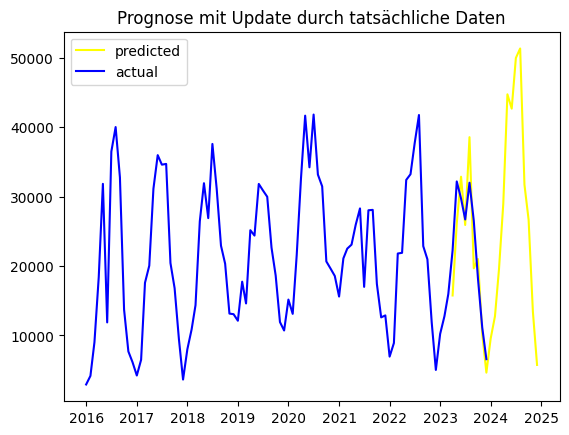

In [930]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2016-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [931]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 3942.5184
mean squared error (mse): ARIMA: 21252147.0141
mean absolute percentage error (mape): ARIMA: 0.1784
